### NFL Matchup Predictions

This Jupyter Notebook walks you though how to use this GitHub repo to predict NFL matchups. All data is directly from NFL.com and can be accessed either in the Data folder or by a Utility function. 

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from matplotlib import pyplot as plt
plt.rcParams['figure.dpi'] = 600
from scipy.stats import pearsonr
import numpy as np

In [2]:
from Utils.dataCollection import defenseDataCollection, offenseDataCollection
from Utils.modelFitting import correlationAnalysis
from Utils.ratingGeneration import offensiveRatingCreation, defensiveRatingCreation, overallRating
from Utils.matchupPredictor import matchup

##### Data Collection

In [3]:
offensiveData = offenseDataCollection()
defensiveData = defenseDataCollection()

In [4]:
offensiveData

,Team Name,PPD,AVG Pass,AVG Rush,TURN,SACKS,TDCR,FDCR,FDP,FDR,W%
0,Arizona Cardinals,2.317,5.0,4.3,-0.016,19.667,0.415,0.429,216.0,91.0,0.176
1,Atlanta Falcons,1.873,5.2,4.5,0.040,8.667,0.333,0.500,185.0,113.0,0.471
2,Baltimore Ravens,2.103,5.6,5.2,-0.024,15.000,0.409,0.600,141.0,146.0,0.471
3,Buffalo Bills,2.230,5.8,5.0,0.008,13.333,0.448,0.594,196.0,146.0,0.706
4,Carolina Panthers,2.016,4.8,4.3,-0.016,11.667,0.361,0.675,170.0,109.0,0.471
5,Chicago Bears,2.452,5.5,4.9,0.175,8.000,0.427,0.517,190.0,142.0,0.647
6,Cincinnati Bengals,2.706,5.2,4.2,-0.032,12.000,0.434,0.700,213.0,102.0,0.353
7,Cleveland Browns,1.683,4.2,3.9,-0.056,17.000,0.336,0.414,134.0,100.0,0.294
8,Dallas Cowboys,2.690,5.7,4.6,-0.071,10.333,0.411,0.629,229.0,120.0,0.438
9,Denver Broncos,2.167,5.2,4.4,-0.024,7.667,0.412,0.500,196.0,111.0,0.824


In [5]:
defensiveData

,Team Name,PPDA,AVG Rush,AVG Pass,INT,SACKS,TDSR,FDSR,W%
0,Arizona Cardinals,1.937,4.4,7.2,10.0,30.0,0.569,0.520,0.176
1,Atlanta Falcons,1.476,4.6,7.1,16.0,57.0,0.601,0.406,0.471
2,Baltimore Ravens,1.857,4.2,7.0,11.0,30.0,0.622,0.439,0.471
3,Buffalo Bills,1.881,5.1,6.2,13.0,36.0,0.586,0.474,0.706
4,Carolina Panthers,1.802,4.4,7.2,15.0,30.0,0.529,0.364,0.471
5,Chicago Bears,1.405,5.0,7.6,23.0,35.0,0.592,0.522,0.647
6,Cincinnati Bengals,1.548,5.2,7.8,13.0,35.0,0.566,0.333,0.353
7,Cleveland Browns,1.421,4.2,6.6,11.0,53.0,0.637,0.611,0.294
8,Dallas Cowboys,2.095,4.7,8.1,6.0,35.0,0.527,0.381,0.438
9,Denver Broncos,1.492,3.9,6.1,10.0,68.0,0.662,0.481,0.824


##### Calculating Weights from Correlation

In [6]:
offensiveWeights = correlationAnalysis(offensiveData)
defensiveWeights = correlationAnalysis(defensiveData)

##### Computing Team Ratings

In [7]:
offensiveRatings = offensiveRatingCreation(offensiveData, offensiveWeights)

In [8]:
defensiveRatings = defensiveRatingCreation(defensiveData, defensiveWeights)

In [9]:
overallRatings = overallRating(offensiveRatings, defensiveRatings)
overallRatings

,Team Name,Offensive Rush Rating,Offensive Pass Rating,Defensive Rush Rating,Defensive Pass Rating,Overall Rating
0,Arizona Cardinals,0.297,0.743,0.092,0.403,0.476
1,Atlanta Falcons,0.682,0.512,0.738,0.674,0.620
2,Baltimore Ravens,0.905,0.090,0.116,0.464,0.328
3,Buffalo Bills,0.935,0.599,0.194,0.604,0.590
4,Carolina Panthers,0.594,0.361,0.116,0.601,0.431
5,Chicago Bears,1.000,0.570,0.283,0.901,0.691
6,Cincinnati Bengals,0.549,0.759,0.237,0.495,0.570
7,Cleveland Browns,0.392,0.000,0.695,0.535,0.324
8,Dallas Cowboys,0.753,0.915,0.140,0.163,0.549
9,Denver Broncos,0.689,0.619,1.000,0.532,0.661


##### Visualization of Correlation Between Overall Rating and Win Percentage

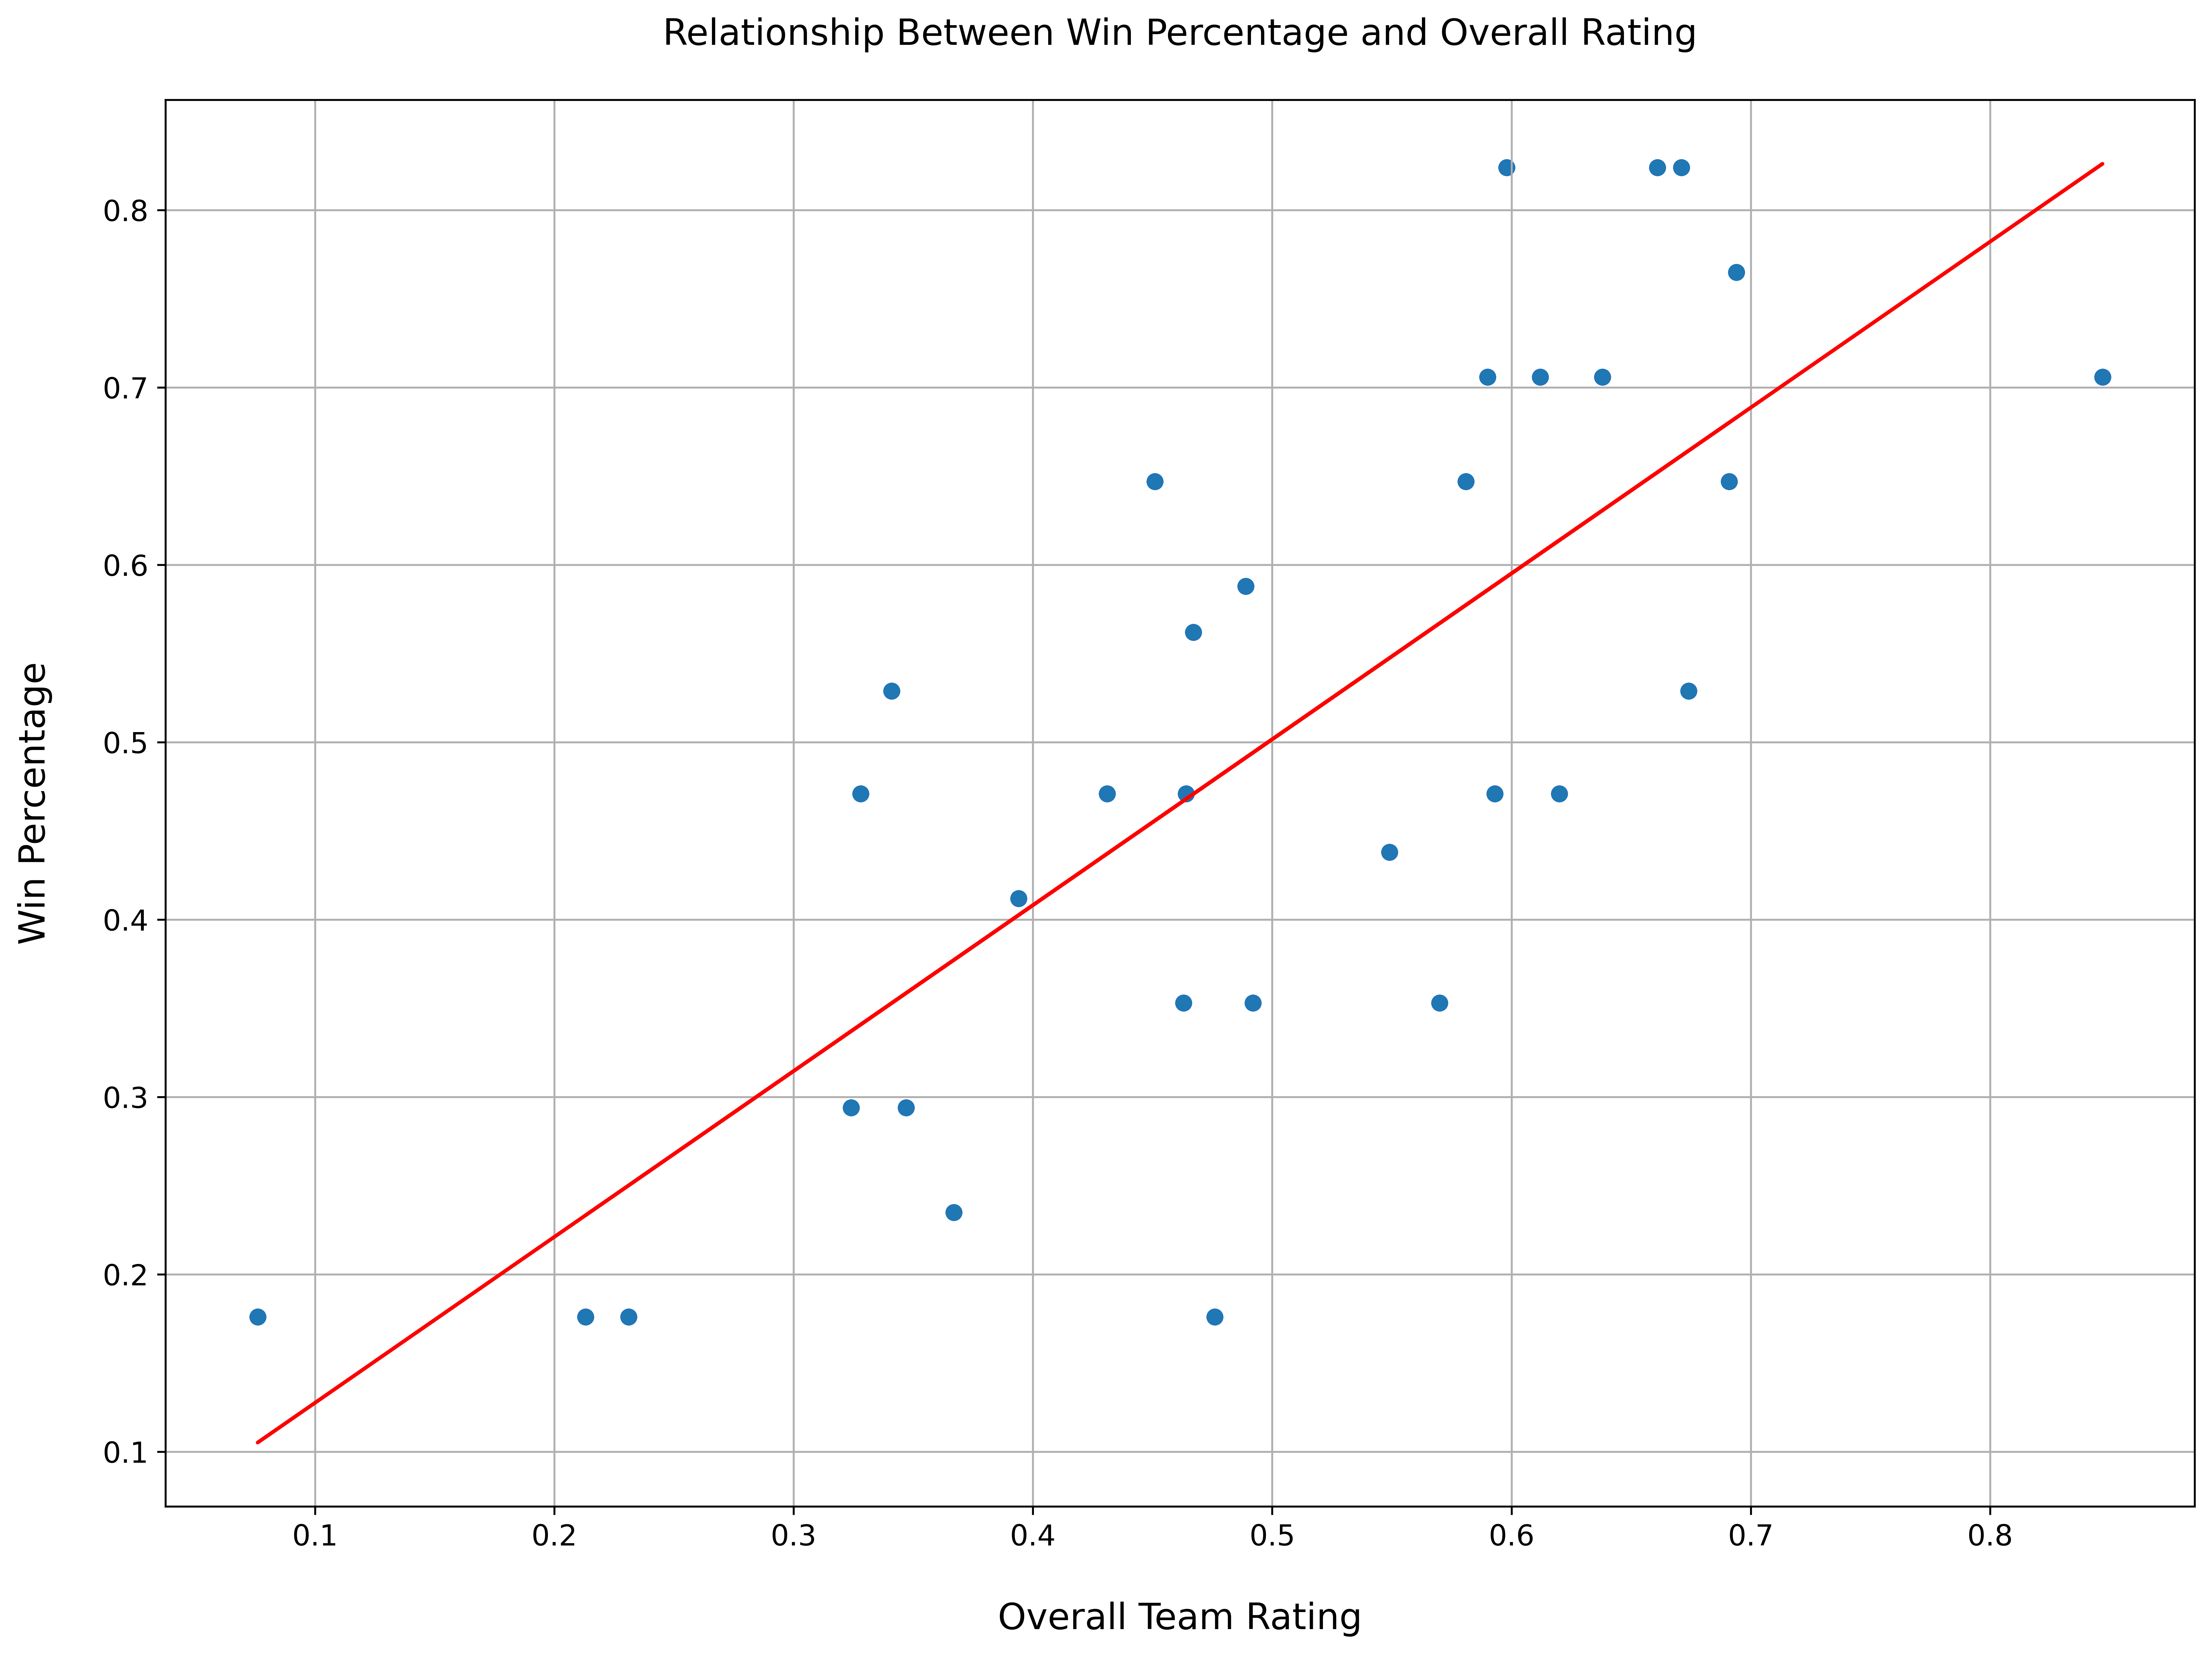

In [10]:
x = overallRatings["Overall Rating"]
y = offensiveData["W%"]

r, pValue = pearsonr(x, y)

plt.title("Relationship Between Win Percentage and Overall Rating\n", fontsize = 15) 
plt.xlabel("\nOverall Team Rating", fontsize = 15)
plt.ylabel("Win Percentage\n", fontsize = 15)
plt.scatter(x, y, color = 'blue')
plt.tight_layout(rect=[0, 0, 2, 2]) 
plt.grid()
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

coefficients = np.polyfit(x, y, 1)  
m, b = coefficients

y_fit = m * x + b

plt.scatter(x, y, label='Data')
plt.plot(x, y_fit, color='red', label='Line of Best Fit')

plt.show()

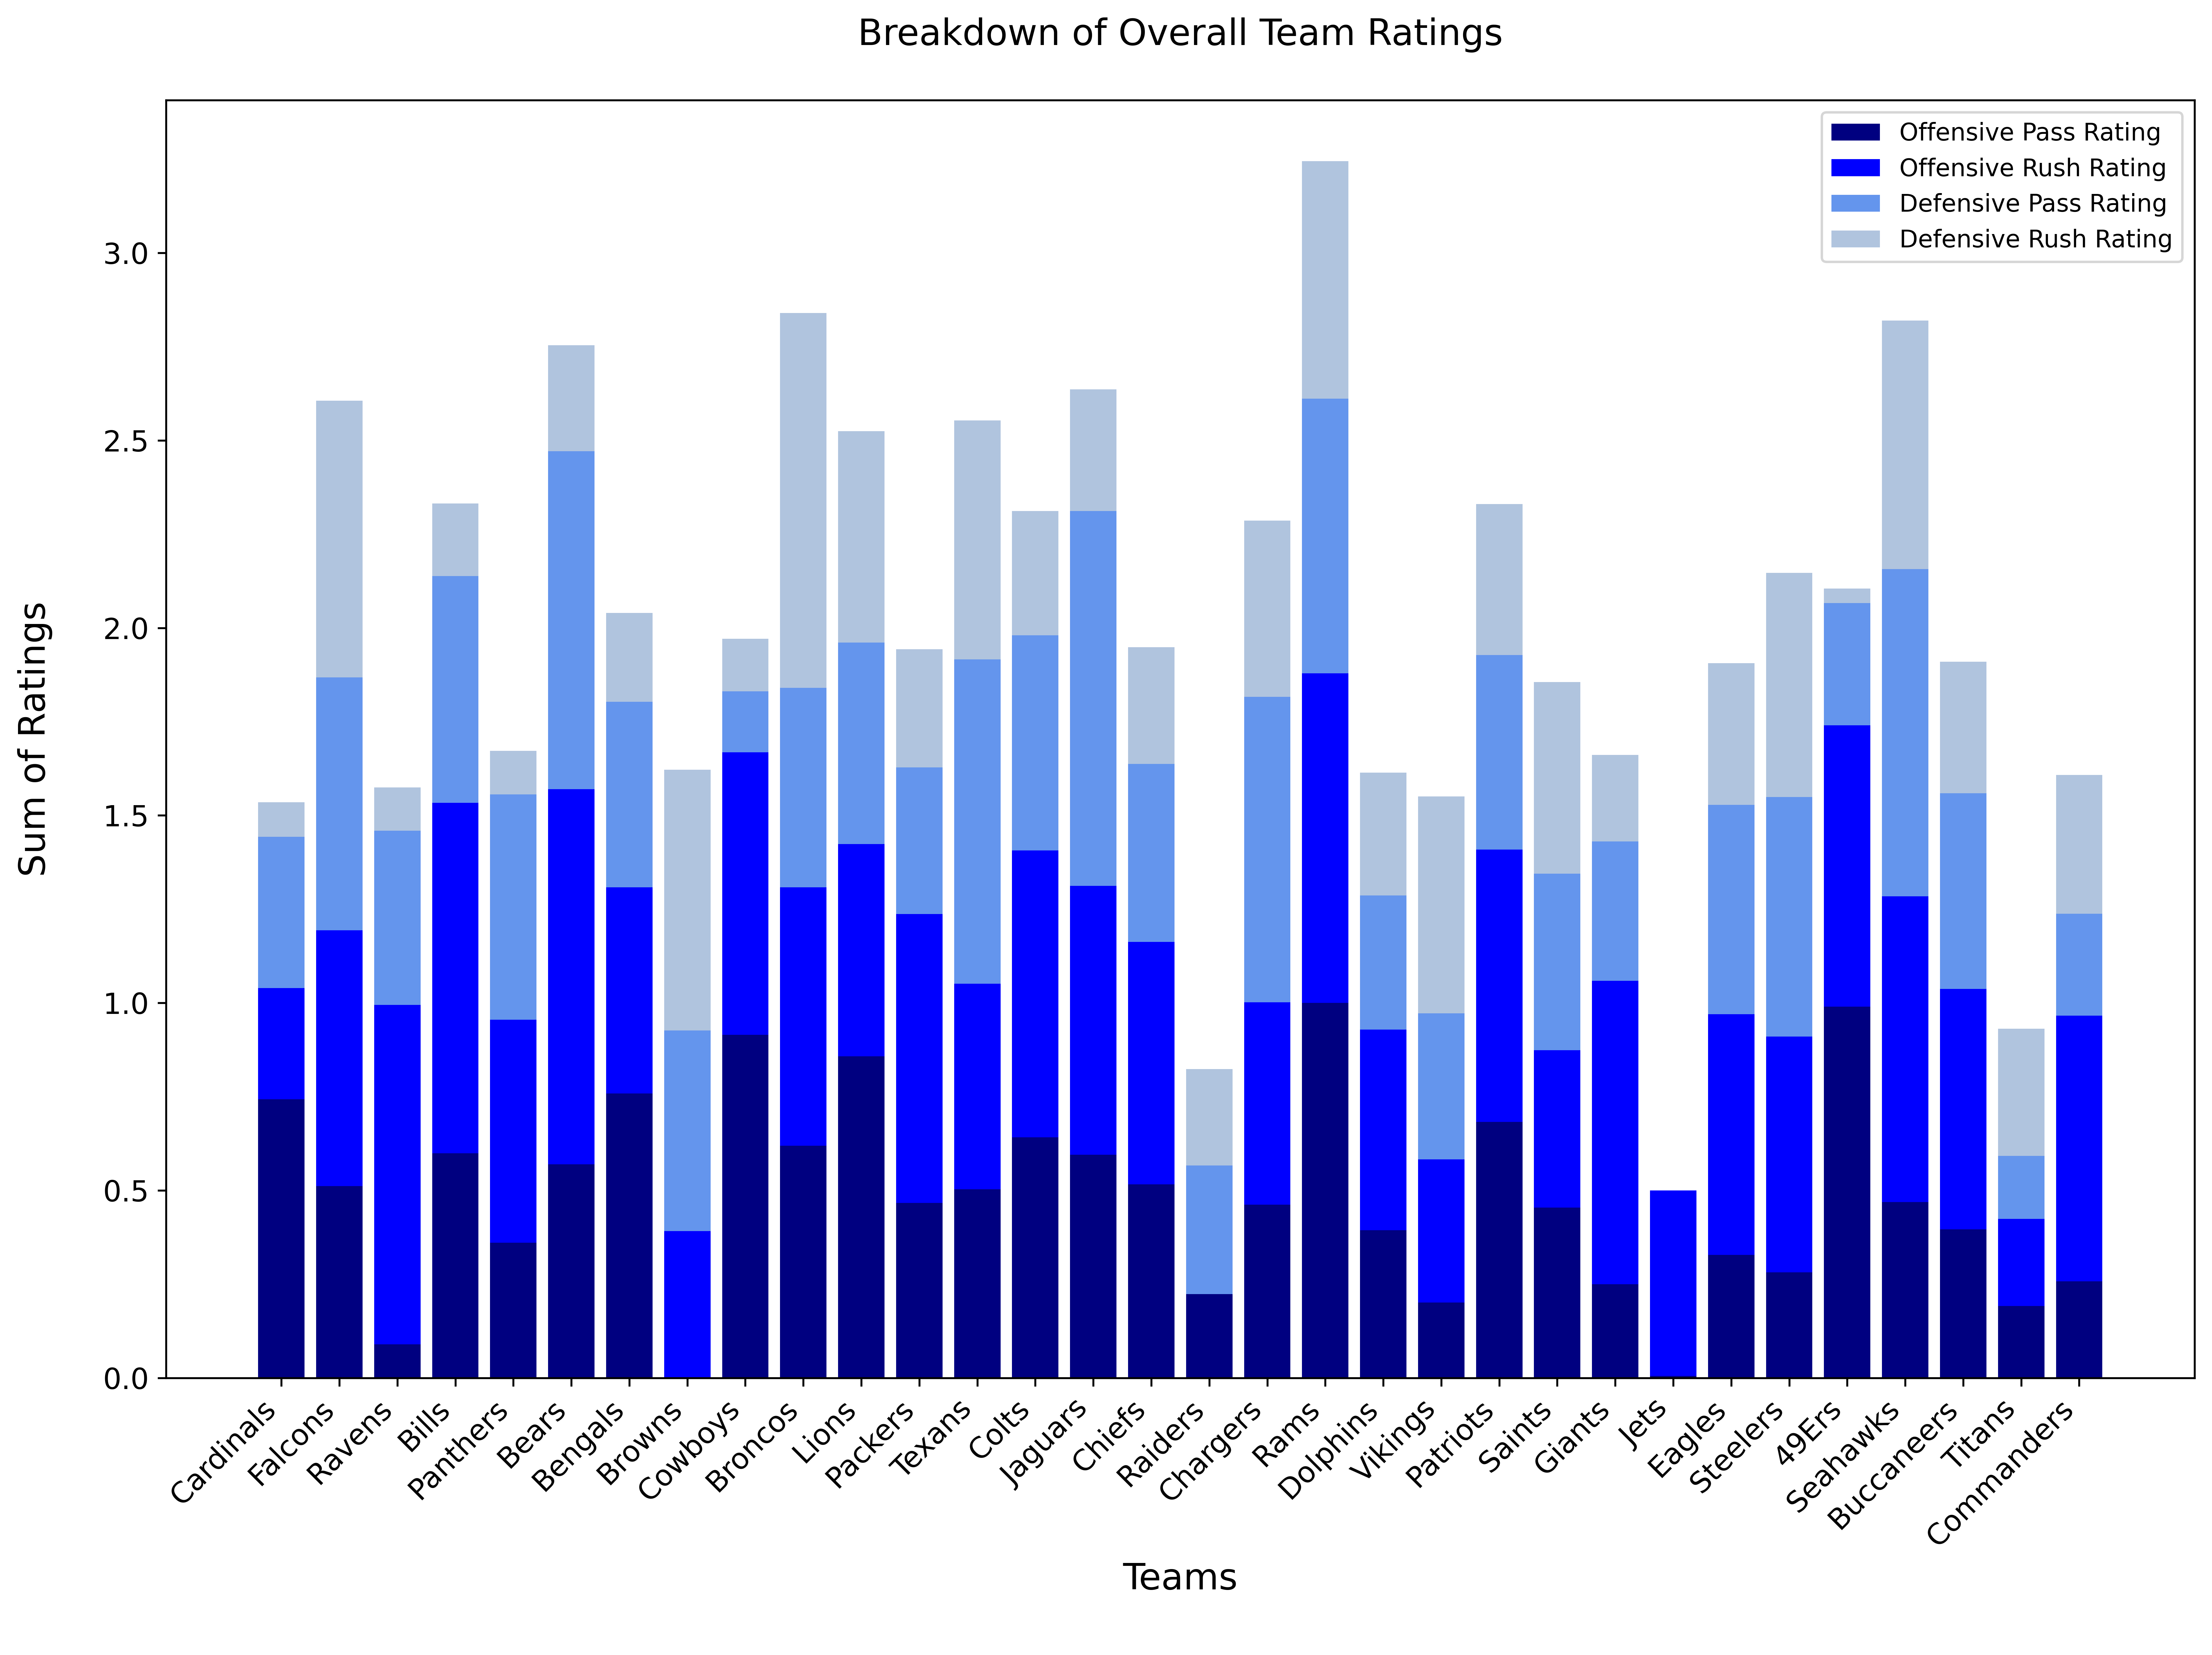

In [11]:
categories = overallRatings["Team Name"].str.split().str[-1]
x = np.arange(len(categories))
barWidth = 0.8

plt.bar(x, overallRatings['Offensive Pass Rating'], width = barWidth, label = 'Offensive Pass Rating', color = 'navy')  
plt.bar(x, overallRatings['Offensive Rush Rating'], width = barWidth, bottom = overallRatings['Offensive Pass Rating'], label = 'Offensive Rush Rating', color = 'blue')  
plt.bar(x, overallRatings['Defensive Pass Rating'], width = barWidth, bottom = overallRatings['Offensive Pass Rating'] + overallRatings['Offensive Rush Rating'], label = 'Defensive Pass Rating', color = 'cornflowerblue')  
plt.bar(x, overallRatings['Defensive Rush Rating'], width = barWidth, bottom = overallRatings['Offensive Pass Rating'] + overallRatings['Offensive Rush Rating'] + overallRatings['Defensive Pass Rating'], label = 'Defensive Rush Rating', color = 'lightsteelblue')

plt.xlabel('Teams\n', fontsize = 15)
plt.ylabel('Sum of Ratings\n', fontsize = 15)
plt.title('Breakdown of Overall Team Ratings\n', fontsize = 15)
plt.legend()
plt.xticks(x, categories, rotation=45, ha='right', fontsize = 12)
plt.yticks(fontsize = 12)
plt.tight_layout(rect=[0, 0, 2, 2]) 

plt.show()

##### Example Matchup Predictions

In [13]:
matchup("San Francisco 49Ers", "Seattle Seahawks", overallRatings)

Projected Winner: Seattle Seahawks
Seattle Seahawks: 52.3%
San Francisco 49Ers: 47.7%

